In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.stats import norm

In [4]:
import os
import urllib.request

# Initialize path and Load in the Ames Housing Data
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/Ames_Housing_Data1.tsv"
data= "Ames_Housing_Data1.db"

if not os.path.exists(data) or os.path.getsize(data) == 0:
    urllib.request.urlretrieve(path, data)

housing = pd.read_csv(data, sep="\t")
housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000


In [5]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            325 non-null    int64  
 1   PID              325 non-null    int64  
 2   MS SubClass      325 non-null    int64  
 3   MS Zoning        325 non-null    str    
 4   Lot Frontage     277 non-null    float64
 5   Lot Area         325 non-null    int64  
 6   Street           325 non-null    str    
 7   Alley            20 non-null     str    
 8   Lot Shape        325 non-null    str    
 9   Land Contour     325 non-null    str    
 10  Utilities        325 non-null    str    
 11  Lot Config       325 non-null    str    
 12  Land Slope       325 non-null    str    
 13  Neighborhood     325 non-null    str    
 14  Condition 1      325 non-null    str    
 15  Condition 2      325 non-null    str    
 16  Bldg Type        325 non-null    str    
 17  House Style      325 non-nu

In [6]:
housing["SalePrice"].describe()

count       325.000000
mean     174591.480000
std       74968.075617
min       12789.000000
25%      128000.000000
50%      158900.000000
75%      206000.000000
max      611657.000000
Name: SalePrice, dtype: float64

In [7]:
housing["Sale Condition"].value_counts()

Sale Condition
Normal     285
Abnorml     22
Partial     13
Family       3
Alloca       2
Name: count, dtype: int64

# Looking for Correlations

In [8]:
#Looking for Correlations

hous_num = housing.select_dtypes(include= ['float64', 'int64'])
hous_num_corr = hous_num.corr()['SalePrice'][:-1] # -1 means that the latest row is SalePrice
top_features = hous_num_corr[abs(hous_num_corr) > 0.5].sort_values(ascending=False) #displays pearsons correlation coefficient greater than 0.5
print("There is {} strongly correlated values with SalePrice:\n{}".format(len(top_features), top_features))

There is 9 strongly correlated values with SalePrice:
Overall Qual      0.761922
Gr Liv Area       0.681422
Total Bsmt SF     0.650713
Garage Cars       0.634792
1st Flr SF        0.624838
Garage Area       0.612205
Year Built        0.594169
Garage Yr Blt     0.554838
Year Remod/Add    0.514439
Name: SalePrice, dtype: float64


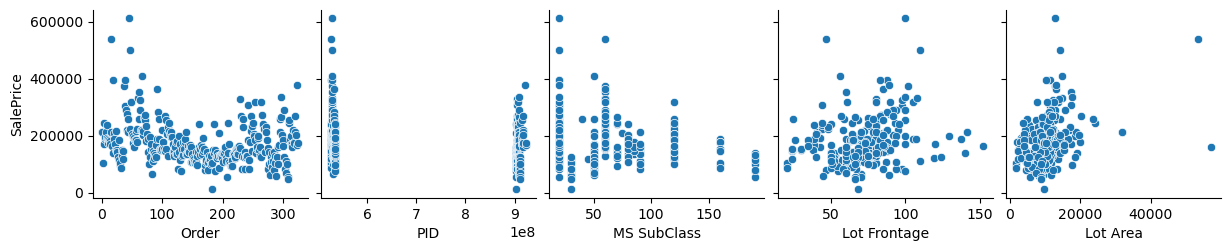

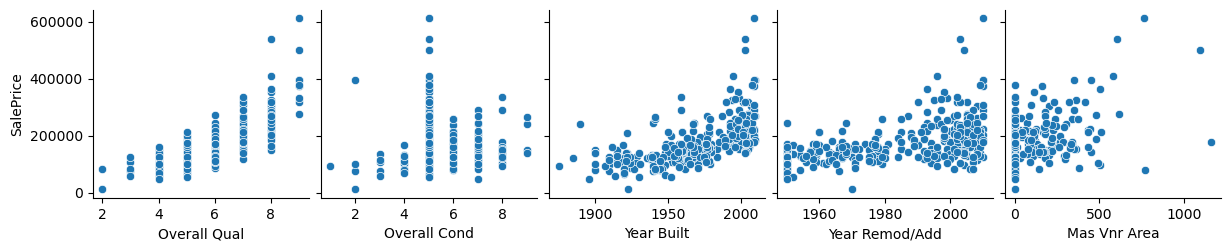

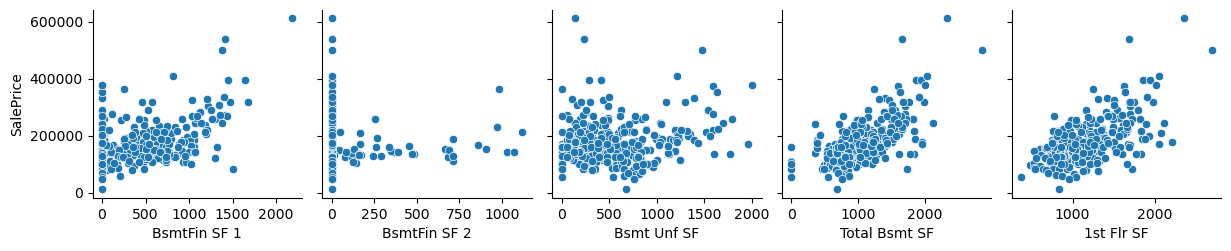

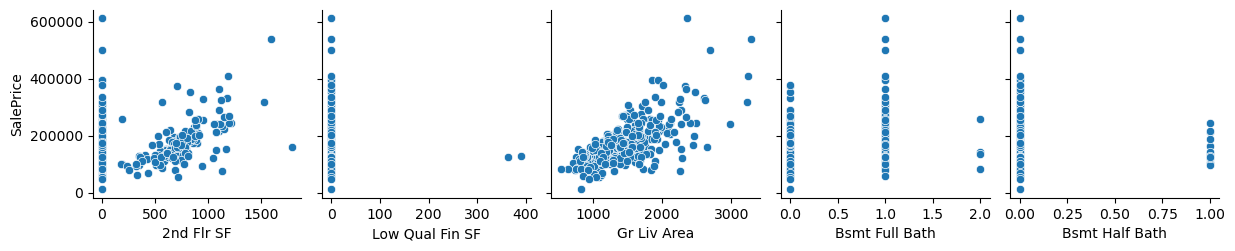

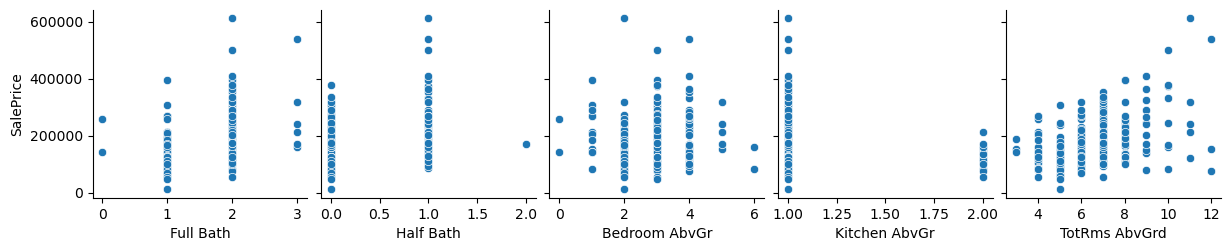

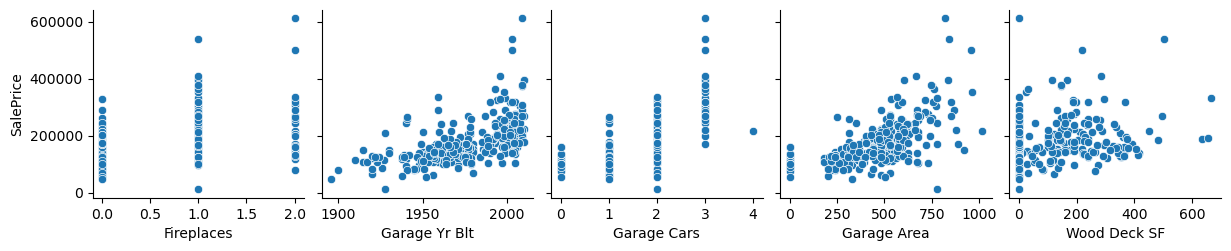

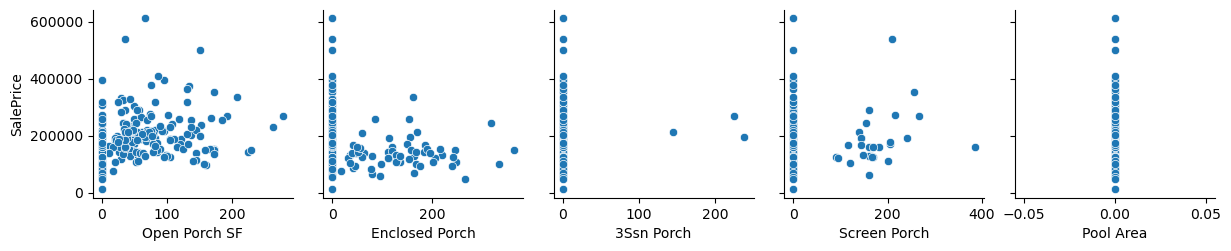

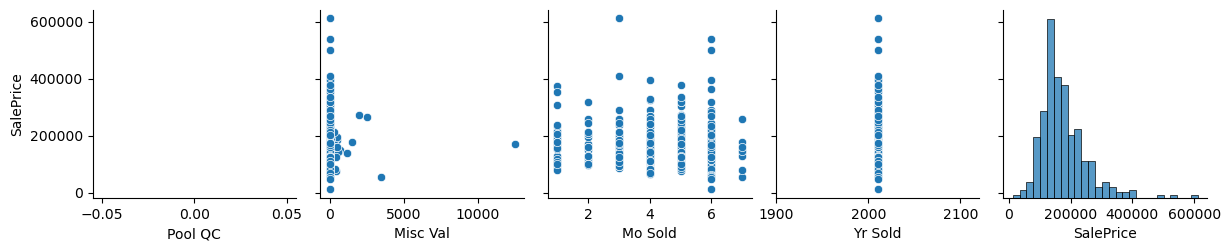

In [9]:
#visually correlation

for i in range(0, len(hous_num.columns), 5):
    sns.pairplot(data= hous_num,
                 x_vars= hous_num.columns[i:i+5],
                 y_vars= ['SalePrice'])

# Log Transformation

C:\Users\Jenovic Kabongo\AppData\Local\Temp\ipykernel_19108\3920264812.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sp_untransformed = sns.distplot(housing['SalePrice'])


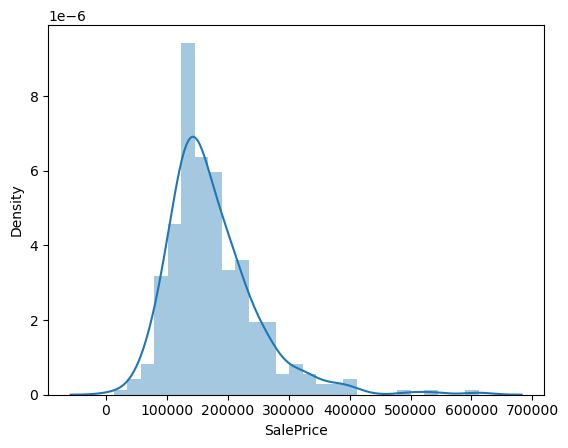

In [15]:
sp_untransformed = sns.distplot(housing['SalePrice'])

In [16]:
print("skweness: %f" % housing['SalePrice'].skew())

skweness: 1.783466


C:\Users\Jenovic Kabongo\AppData\Local\Temp\ipykernel_19108\3256946836.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sp_transformed = sns.distplot(log_transformed)


skewness: -0.557049


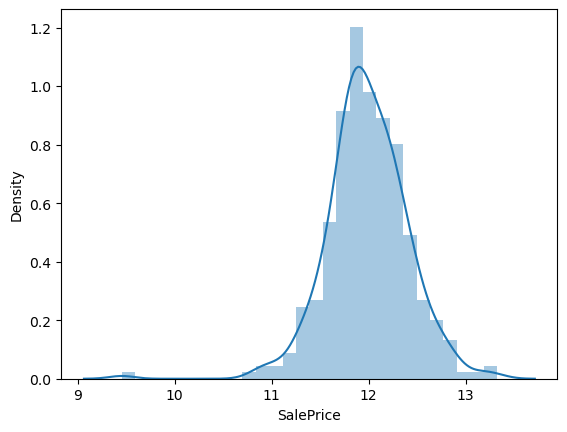

In [19]:
log_transformed = np.log(housing['SalePrice'])
sp_transformed = sns.distplot(log_transformed)
print("skewness: %f" % (log_transformed).skew())

# Exercise 2

In this exercise, visually inspect the 'Lot Area' feature. If there is any skewness present, apply log transform to make it more normally distributed.

C:\Users\Jenovic Kabongo\AppData\Local\Temp\ipykernel_19108\2952468094.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  la_untransformed = sns.distplot(housing['Lot Area'])


Skewness: 4.198414


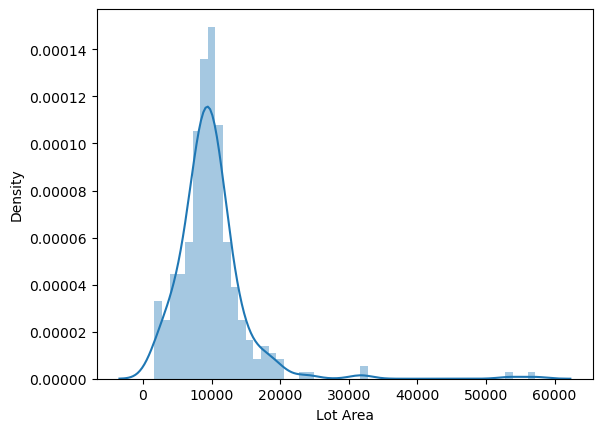

In [22]:
la_untransformed = sns.distplot(housing['Lot Area'])
print("Skewness: %f" % housing['Lot Area'].skew())

skewness: -0.589689


C:\Users\Jenovic Kabongo\AppData\Local\Temp\ipykernel_19108\2992267812.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(la_transformed)


<Axes: xlabel='Lot Area', ylabel='Density'>

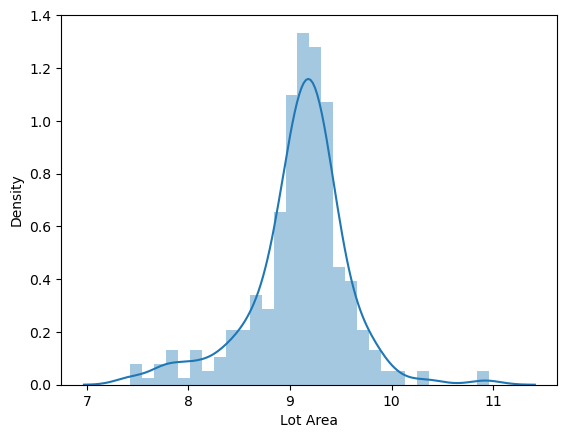

In [24]:
la_transformed = np.log(housing['Lot Area'])
print("skewness: %f" % la_transformed.skew())
sns.distplot(la_transformed)

# Handling the Duplicates

In [25]:
duplicate = housing[housing.duplicated(['PID'])]
duplicate

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000


In [28]:
dup_duplicate = housing.drop_duplicates()
dup_duplicate

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,320,916455170,60,RL,80.0,11316,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,2,2010,WD,Normal,214900
321,321,916475110,60,RL,85.0,14191,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,202900
322,322,921128020,20,RL,89.0,13214,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,378500
323,323,923201020,20,RL,85.0,15300,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,169000


In [29]:
housing.index.is_unique

True

# Exercise 3
In this exercise try to remove duplicates on a specific column by setting the subset equal to the column that contains the duplicate, such as 'Order'.

In [31]:
remove_sub = housing.drop_duplicates(subset=['Order'])

# Handling the Missing Values
### Finding the Missing Values

Text(0.5, 1.0, 'Missing values')

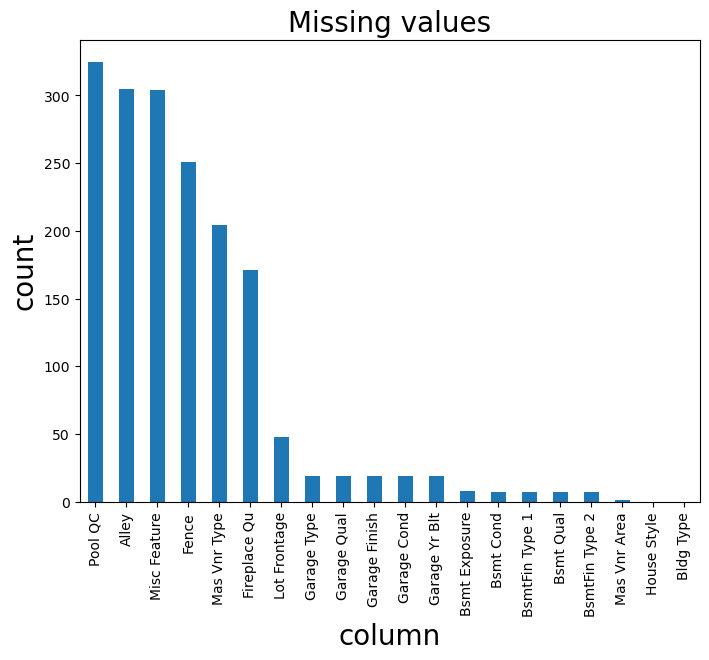

In [32]:
total = housing.isnull().sum().sort_values(ascending=False)
total_select = total.head(20)
total_select.plot(kind='bar', figsize = (8,6), fontsize = 10)

plt.xlabel('column', fontsize = 20)
plt.ylabel('count', fontsize = 20)
plt.title('Missing values', fontsize = 20)

In [33]:
housing.dropna(subset=['Lot Frontage'])

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,320,916455170,60,RL,80.0,11316,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,2,2010,WD,Normal,214900
321,321,916475110,60,RL,85.0,14191,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,202900
322,322,921128020,20,RL,89.0,13214,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,378500
323,323,923201020,20,RL,85.0,15300,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,169000


In [35]:
housing.drop('Lot Frontage', axis=1)

,Order,PID,MS SubClass,MS Zoning,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,320,916455170,60,RL,11316,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2010,WD,Normal,214900
321,321,916475110,60,RL,14191,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,202900
322,322,921128020,20,RL,13214,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,378500
323,323,923201020,20,RL,15300,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,169000


In [36]:
median = housing['Lot Frontage'].median()
median

70.0

In [39]:
housing['Lot Frontage'].fillna(median, inplace=True)
housing['Lot Frontage'].tail()

C:\Users\Jenovic Kabongo\AppData\Local\Temp\ipykernel_19108\3859705536.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  housing['Lot Frontage'].fillna(median, inplace=True)


320    80.0
321    85.0
322    89.0
323    85.0
324    93.0
Name: Lot Frontage, dtype: float64

# Exercise 4
In this exercise, let's look at 'Mas Vnr Area' feature and replace the missing values with the mean value of that column.

In [40]:
housing['Mas Vnr Area'].isnull

<bound method Series.isnull of 0      112.0
1      112.0
2        0.0
3      108.0
4        0.0
       ...  
320     44.0
321      0.0
322      0.0
323      0.0
324      0.0
Name: Mas Vnr Area, Length: 325, dtype: float64>

In [42]:
mean = housing['Mas Vnr Area'].mean()
housing['Mas Vnr Area'].fillna(mean, inplace=True)
housing['Mas Vnr Area'].tail()

C:\Users\Jenovic Kabongo\AppData\Local\Temp\ipykernel_19108\822711218.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  housing['Mas Vnr Area'].fillna(mean, inplace=True)


320    44.0
321     0.0
322     0.0
323     0.0
324     0.0
Name: Mas Vnr Area, dtype: float64

### Feature Scaling

One of the most important transformations we need to apply to our data is feature scaling. There are two common ways to get all attributes to have the same scale: min-max scaling and standardization.

Min-max scaling (or normalization) is the simplest: values are shifted and rescaled so they end up ranging from 0 to 1. This is done by subtracting the min value and dividing by the max minus min.

Standardization is different: first it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation, so that the resulting distribution has unit variance.